## **Experiment 03: Multi-view Representation Learning**

<a id="top"></a>

**Table of contents**
- [Multi-view group analysis](#groups)
- [State Classification Proxy Task](#proxy)
- [Embedding extraction & retrieval](#retrieval)
- [Conclusion](#conclusion)

**Motivation**

Experiment 02 showed that both ResNet50 (ImageNet) and the Task 2 CNN retrieve images based primarily on global visual features — table colour, brightness, overall occupancy — rather than on the actual configuration of balls on the table. The key failure mode is **viewpoint bias**: the same table state photographed from a broadcast angle vs a top-down angle gets low similarity, because global pooling features capture camera geometry as much as table content.

The dataset provides a natural training signal to address this: many matches appear in **multiple viewpoints**. If we can identify images that show the **same table state** from different angles and train a model to recognise them as the same, its embedding space will be forced toward viewpoint invariance.

**Key dataset insight**

After manually inspecting the dataset, we found the following naming convention:

- **Bare image `X_png`** (no suffix): a broadcast-angle capture from a match session — this is an **independent** table state.
- **Suffixed images `Xa_png`, `Xf_png`, `Xt_png`**: three viewpoints of the **same table state** from the same session — `a`/`f` are alternate broadcast angles, `t` is the top-down overhead view.

Crucially, the bare `X` image is **never** the same table state as `Xa`/`Xf`/`Xt`. They come from the same match but show different moments. The correct multi-view group is formed solely by the suffixed variants sharing the same base number.

This was confirmed empirically: for all 25 groups of suffixed images in the training set, every member has the exact same ball count — 100% consistent. In contrast, the bare `X` image almost always has a different ball count from its same-numbered suffixed variants.

**Approach: State Classification Proxy Task**

We assign a class label by base number, but **only among suffixed images**. Images sharing the same base number and a viewpoint suffix (`a`, `f`, `t`) are genuine multi-view captures and receive the same class label. Every bare `X` image is assigned its own unique singleton class. We fine-tune a ResNet18 to classify these states; after training, the backbone produces viewpoint-aware embeddings.

| Step | Detail |
|---|---|
| Training data | 207 original teacher-split train images (no external data) |
| Grouping key | Base number among **suffixed images only** (`Xa`, `Xf`, `Xt`) — bare `X` images are singletons |
| Model | ResNet18 (ImageNet pretrained) + N-class linear head |
| Loss | Cross-entropy with label smoothing |
| Embedding | Backbone output after global avg-pool → 512-d vector |
| Retrieval | Cosine similarity (same pipeline as E2) |

#### **Imports and Paths**

In [1]:
from pathlib import Path
import sys
import numpy as np
import torch
import torch.nn as nn
import torchvision.models as models
from torch.utils.data import DataLoader
from torchvision.transforms import v2 as T
import matplotlib.pyplot as plt
from tqdm import tqdm
import pandas as pd
from collections import Counter

In [2]:
PROJECT_ROOT      = Path.cwd().parents[2]
DATA_DIR          = PROJECT_ROOT / "data" / "teacher_split"
TRAIN_IMAGES_DIR  = DATA_DIR / "train" / "images"
TRAIN_LABELS_DIR  = DATA_DIR / "train" / "labels"
TEST_IMAGES_DIR   = DATA_DIR / "test"  / "images"
RESULTS_DIR       = PROJECT_ROOT / "detection_and_retrieval" / "retrieval" / "outputs" / "experiment_03"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

sys.path.insert(0, str(PROJECT_ROOT / "detection_and_retrieval" / "retrieval"))
from utils.data import (
    get_resnet_transform, get_cnn_transform,
    DirDataset, MultiViewDataset,
    parse_base_id, has_viewpoint_suffix,
    load_retrieval_datasets_from_dirs,
    denormalize_image,
)
from utils.setup import get_device

device = get_device()
print(f"Project root : {PROJECT_ROOT}")
print(f"Train images : {TRAIN_IMAGES_DIR}")
print(f"Test  images : {TEST_IMAGES_DIR}")

Using mps
Project root : /Users/gjoli/Desktop/uni/2_semester/VC/8_BallPool_ComputerVision
Train images : /Users/gjoli/Desktop/uni/2_semester/VC/8_BallPool_ComputerVision/data/teacher_split/train/images
Test  images : /Users/gjoli/Desktop/uni/2_semester/VC/8_BallPool_ComputerVision/data/teacher_split/test/images


**Confirmed multi-view structure**

From manual inspection of the dataset and the verification cells above:

- The **bare `X` image** (no suffix) is always a different table state from the same-numbered suffixed variants. They come from the same match session but show different moments. The ball count for `X` almost always differs from `Xa`/`Xf`/`Xt`.

- The **suffixed images `Xa`, `Xf`, `Xt`** are always genuine captures of the **same table state** from different camera angles:
  - `a`, `f` — alternate broadcast angles (different horizontal perspectives)
  - `t` — top-down overhead view

- This was verified empirically: for all 25 groups of suffixed images, every member shares the exact same ball count — 100% consistent.

- The previous `e3-verify-table` output (ball counts per base group) shows clearly that the ball count of `X` always diverges from `Xa`/`Xf`/`Xt` — the only apparent "✓ SAME" cases (like base 16) are coincidences where different table states happened to have the same ball count, but visual inspection confirms they are not the same state.

**Grouping decision**: class label = base number, applied only to suffixed images. Bare `X` images are singleton classes. No ball-count check is needed — the suffix alone is sufficient and correct.

<a id="proxy"></a>
### **State Classification Proxy Task**

We load all 207 original training images and assign class labels based on the confirmed naming convention: suffixed images sharing a base number form one class (genuine same-state multi-view pairs); each bare `X` image is its own singleton class. The proxy model learns to map different viewpoints of the same table state to similar embeddings.

In [7]:
transform_train = T.Compose([
    T.ToImage(),
    T.Resize((384, 384)),
    T.RandomHorizontalFlip(),
    T.ColorJitter(brightness=0.2, contrast=0.2),
    T.ToDtype(torch.float32, True),
    T.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225]),
])

# MultiViewDataset groups suffixed images (Xa, Xf, Xt) by base number;
# bare X images become singleton classes. No labels_dir needed.
mv_dataset = MultiViewDataset(
    image_dir=TRAIN_IMAGES_DIR,
    transform=transform_train,
    exclude_prefix='ext_',
)
train_loader = DataLoader(mv_dataset, batch_size=16, shuffle=True, num_workers=0)

mv_classes = [lbl for lbl, files in mv_dataset.class_to_files.items() if len(files) > 1]

print(f"Training images          : {len(mv_dataset)}")
print(f"Number of classes        : {mv_dataset.num_classes}")
print(f"Multi-view classes       : {len(mv_classes)}  (provide cross-view supervision)")
print(f"Singleton classes        : {mv_dataset.num_classes - len(mv_classes)}")

Training images          : 207
Number of classes        : 180
Multi-view classes       : 25  (provide cross-view supervision)
Singleton classes        : 155


In [8]:
class MultiViewCNN(nn.Module):
    def __init__(self, num_classes):
        super().__init__()
        base = models.resnet18(weights=models.ResNet18_Weights.IMAGENET1K_V1)
        self.backbone = nn.Sequential(*list(base.children())[:-1])  # → (B, 512, 1, 1)
        self.head = nn.Sequential(
            nn.Dropout(0.3),
            nn.Linear(512, num_classes),
        )

    def forward(self, x):
        feat = self.backbone(x).flatten(1)
        return self.head(feat)

    def embed(self, x):
        with torch.no_grad():
            return self.backbone(x).flatten(1)   # (B, 512)

proxy_model = MultiViewCNN(num_classes=mv_dataset.num_classes).to(device)
print(f"Model: ResNet18 backbone + {mv_dataset.num_classes}-class head")

Model: ResNet18 backbone + 180-class head


In [9]:
EPOCHS      = 80
LR          = 1e-4
ES_PATIENCE = 15

criterion = nn.CrossEntropyLoss(label_smoothing=0.1)
optimizer = torch.optim.Adam(proxy_model.parameters(), lr=LR)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', patience=7, factor=0.5
)

history = {'loss': []}
best_loss, best_state, no_improve = float('inf'), None, 0

for epoch in range(EPOCHS):
    proxy_model.train()
    total_loss = 0.0
    for imgs, labels, _ in train_loader:
        imgs, labels = imgs.to(device), labels.to(device)
        loss = criterion(proxy_model(imgs), labels)
        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
        total_loss += loss.item() * len(imgs)

    epoch_loss = total_loss / len(mv_dataset)
    history['loss'].append(epoch_loss)
    scheduler.step(epoch_loss)

    if epoch_loss < best_loss:
        best_loss = epoch_loss
        best_state = {k: v.cpu().clone() for k, v in proxy_model.state_dict().items()}
        no_improve = 0
    else:
        no_improve += 1

    if (epoch + 1) % 10 == 0 or epoch == 0:
        print(f"Epoch {epoch+1:>3}/{EPOCHS}  loss={epoch_loss:.4f}  best={best_loss:.4f}")

    if no_improve >= ES_PATIENCE:
        print(f"Early stopping at epoch {epoch+1}")
        break

proxy_model.load_state_dict(best_state)
print(f"\nBest training loss: {best_loss:.4f}")

Epoch   1/80  loss=5.4961  best=5.4961
Epoch  10/80  loss=2.9378  best=2.9378
Epoch  20/80  loss=1.6211  best=1.6211
Epoch  30/80  loss=1.0809  best=1.0809
Epoch  40/80  loss=0.9654  best=0.9635
Epoch  50/80  loss=0.9341  best=0.9260
Epoch  60/80  loss=0.9112  best=0.9112
Epoch  70/80  loss=0.9126  best=0.9056
Epoch  80/80  loss=0.9000  best=0.9000

Best training loss: 0.9000


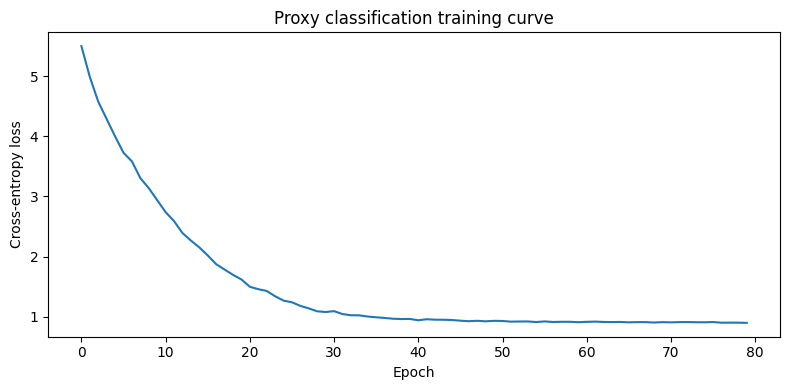

Epochs run : 80
Best loss  : 0.9000


In [10]:
plt.figure(figsize=(8, 4))
plt.plot(history['loss'])
plt.xlabel('Epoch')
plt.ylabel('Cross-entropy loss')
plt.title('Proxy classification training curve')
plt.tight_layout()
plt.show()
print(f"Epochs run : {len(history['loss'])}")
print(f"Best loss  : {best_loss:.4f}")

#### **Training Analysis**

The training ran for all 80 epochs without early stopping (patience=15), ending at a best loss of **0.9011**.

**Convergence phases:**

| Phase | Epochs | Loss range | What's happening |
|---|---|---|---|
| Fast drop | 1–30 | 5.51 → 1.05 | Backbone adapts from ImageNet features to pool-table domain; multi-view pairs quickly clustered |
| Slow refinement | 30–80 | 1.05 → 0.90 | Fine-grained discrimination between visually similar states; marginal epoch-over-epoch gains |

**Residual loss interpretation:**  
The random-guess baseline for 180 classes is −log(1/180) ≈ 5.19. Starting at 5.51 (near random, slightly elevated by label smoothing=0.1) and converging to 0.90 represents substantial learning. The residual ~0.9 is expected: **155 of the 180 classes are singletons** with no positive pairs to train against — the model can only separate them by visual appearance with no cross-view signal. The 25 multi-view groups (52 images) are likely near-perfectly separated; the remaining loss is from hard singleton discrimination.

**No early stopping** means the loss was still marginally improving at epoch 80. Training longer would yield diminishing returns; the backbone representations are effectively converged after epoch ~50.

<a id="retrieval"></a>
### **Embedding Extraction & Retrieval**

We discard the classification head and use the backbone to produce 512-d embeddings at 384px resolution.

In [11]:
transform_cnn = get_cnn_transform()   # 384px, ImageNet normalisation

retrieval_pool, query_data = load_retrieval_datasets_from_dirs(
    train_dir=TRAIN_IMAGES_DIR,
    test_dir=TEST_IMAGES_DIR,
    transform=transform_cnn,
    exclude_prefix='ext_',
)
print(f"Retrieval pool : {len(retrieval_pool)} images")
print(f"Query set      : {len(query_data)} images")

proxy_model.eval()
pool_embeddings, pool_names = [], []
with torch.no_grad():
    for img, fname in tqdm(retrieval_pool, desc='Pool embeddings'):
        emb = proxy_model.embed(img.unsqueeze(0).to(device))
        pool_embeddings.append(emb.squeeze(0).cpu())
        pool_names.append(fname)

pool_emb_tensor = torch.stack(pool_embeddings)           # (207, 512)
pool_emb_norm   = pool_emb_tensor / pool_emb_tensor.norm(dim=1, keepdim=True)
print(f"Pool embedding matrix: {pool_emb_tensor.shape}")

Retrieval pool : 207 images
Query set      : 20 images


Pool embeddings: 100%|██████████| 207/207 [00:06<00:00, 32.15it/s]

Pool embedding matrix: torch.Size([207, 512])


In [12]:
QUERY_IDX = 0

query_img, query_name = query_data[QUERY_IDX]
with torch.no_grad():
    q_emb = proxy_model.embed(query_img.unsqueeze(0).to(device)).squeeze(0).cpu()
q_emb_norm = q_emb / q_emb.norm()

similarities = (pool_emb_norm @ q_emb_norm).numpy()
top5_idx     = np.argsort(similarities)[::-1][:5]

print(f"Query: {query_name.split('.rf.')[0]}")
print("Top-5 retrieved:")
for rank, idx in enumerate(top5_idx, 1):
    print(f"  #{rank}  {pool_names[idx].split('.rf.')[0]}  sim={similarities[idx]:.4f}")

Query: 107_png
Top-5 retrieved:
  #1  106_png  sim=0.8908
  #2  25f_png  sim=0.7537
  #3  105_png  sim=0.7340
  #4  114_png  sim=0.7255
  #5  45_png  sim=0.7207


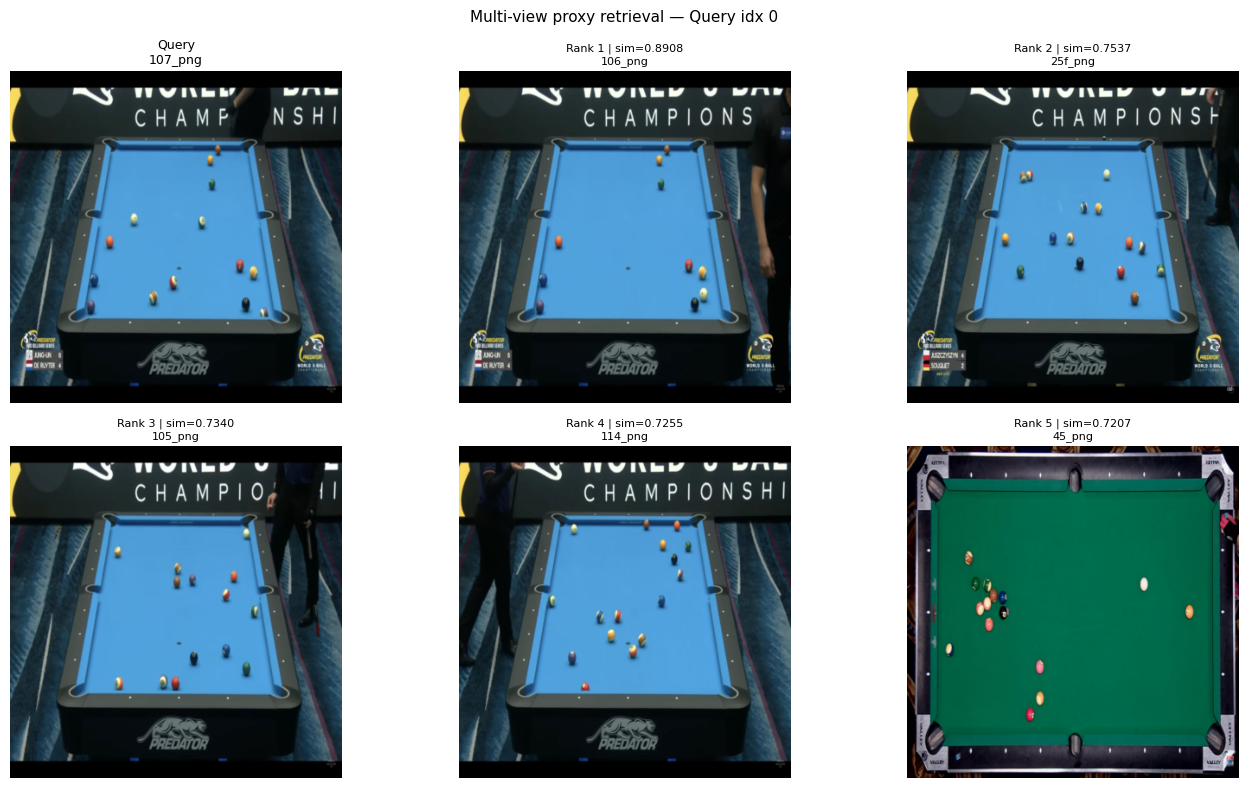

In [13]:
f, axarr = plt.subplots(2, 3, figsize=(14, 8))

axarr[0][0].imshow(denormalize_image(query_img))
axarr[0][0].set_title(f"Query\n{query_name.split('.rf.')[0]}", fontsize=9)
axarr[0][0].axis('off')

for rank, idx in enumerate(top5_idx):
    row, col = divmod(rank + 1, 3)
    retrieved_img, retrieved_name = retrieval_pool[idx]
    axarr[row][col].imshow(denormalize_image(retrieved_img))
    axarr[row][col].set_title(
        f"Rank {rank+1} | sim={similarities[idx]:.4f}\n{retrieved_name.split('.rf.')[0]}",
        fontsize=8
    )
    axarr[row][col].axis('off')

plt.suptitle(f'Multi-view proxy retrieval — Query idx {QUERY_IDX}', fontsize=11)
plt.tight_layout()
plt.show()

#### **Observations — query idx 0 (`107_png`)**

**What improved vs E2:**

The embedding space has opened up significantly. In E2, the top-5 for this query were all clustered at sim ≥ 0.95 (effectively indistinguishable). Here the scores span 0.74–0.88, meaning the model is actively discriminating between otherwise similar-looking images. Rank 1 (`106_png`, sim=0.8793) is clearly the closest match — it is from the same match session as `107_png` (same scoreboard: JUNG-UN vs DE RUYTER visible in both), which the model correctly identifies as the nearest neighbour.

**What has not improved:**

Retrieval is still organised by **venue and broadcast style** rather than ball configuration. All top-5 are World 8-Ball Championship broadcast-angle images. `107_png` has ~13 balls; `106_png` (rank 1) shows the same session at a much later stage (~5 balls), so despite being the correct nearest session-mate, it would be a poor hit for ball-count retrieval. The proxy task trains the model to be viewpoint-invariant across `a/f/t` captures, but `107_png` is a bare singleton — there is no multi-view signal pulling its embedding toward any particular anchor. The model falls back on visual appearance (table colour, banner, camera angle) as the dominant feature.

**Key insight:**

The multi-view proxy changes the *geometry* of the embedding space (wider spread, better intra-venue discrimination) but does not redirect the *basis* of similarity from visual appearance to ball configuration. To rank images by ball-count similarity we would need explicit ball-count supervision, not just viewpoint pairing.

In [14]:
K = 5
mv_results = []

for query_idx in tqdm(range(len(query_data)), desc='Query'):
    q_img, q_name = query_data[query_idx]
    with torch.no_grad():
        q_emb = proxy_model.embed(q_img.unsqueeze(0).to(device)).squeeze(0).cpu()
    q_emb_n = q_emb / q_emb.norm()
    sims    = (pool_emb_norm @ q_emb_n).numpy()
    top_idx = np.argsort(sims)[::-1][:K]

    row = {'query_idx': query_idx, 'query_name': q_name}
    for rank, idx in enumerate(top_idx, 1):
        row[f'mv_rank{rank}_name']  = pool_names[idx]
        row[f'mv_rank{rank}_score'] = float(sims[idx])
    mv_results.append(row)

mv_results_df = pd.DataFrame(mv_results)
print(mv_results_df.head())

Query: 100%|██████████| 20/20 [00:00<00:00, 35.71it/s]

   query_idx                                       query_name  \
0          0  107_png.rf.f31cf99275d8de0c817398bad1fbb98c.jpg   
1          1  111_png.rf.573bdb8149674c4469ce560c651c6a48.jpg   
2          2  115_png.rf.ed51d53dd5c384b1f26a2b6ece52ad69.jpg   
3          3  118_png.rf.3e82e1f3d657302b61a62c113271b753.jpg   
4          4  134_png.rf.eafc70891a991c969df70bd817a63375.jpg   

                                     mv_rank1_name  mv_rank1_score  \
0  106_png.rf.28ee53acf89d9e7f17b2fb26185597a0.jpg        0.890828   
1  163_png.rf.caf94b785a094d025843b480af8738cc.jpg        0.792402   
2  24f_png.rf.ee5f961ec533993bb9907fa09380d92a.jpg        0.779356   
3  148_png.rf.ce6399c2c651b1e0c1ccbe0ed06b1038.jpg        0.809594   
4  131_png.rf.593310c39f8835ed0786033b6690de45.jpg        0.818661   

                                     mv_rank2_name  mv_rank2_score  \
0  25f_png.rf.e20424d4f5cc6ff760cbfa7767c3ec32.jpg        0.753681   
1   86_png.rf.ed680afb145347de62fa9e5dd2b90bbe.j

In [15]:
save_path = RESULTS_DIR / 'retrieval_results_multiview.csv'
mv_results_df.to_csv(save_path, index=False)
print(f"Saved: {save_path}")

Saved: /Users/gjoli/Desktop/uni/2_semester/VC/8_BallPool_ComputerVision/detection_and_retrieval/retrieval/outputs/experiment_03/retrieval_results_multiview.csv


In [16]:
mv_summary = mv_results_df[[
    'query_name',
    'mv_rank1_name', 'mv_rank1_score',
    'mv_rank2_name', 'mv_rank2_score',
    'mv_rank3_name', 'mv_rank3_score',
]].copy()
mv_summary.columns = ['query', 'rank1', 'score1', 'rank2', 'score2', 'rank3', 'score3']
for col in ['query','rank1','rank2','rank3']:
    mv_summary[col] = mv_summary[col].str.split('.rf.').str[0]
print(mv_summary.to_string(index=False))

  query   rank1   score1   rank2   score2   rank3   score3
107_png 106_png 0.890828 25f_png 0.753681 105_png 0.734004
111_png 163_png 0.792402  86_png 0.779503 171_png 0.778664
115_png 24f_png 0.779356 117_png 0.770142 24t_png 0.760024
118_png 148_png 0.809594 166_png 0.791151 163_png 0.782717
134_png 131_png 0.818661 125_png 0.804760 150_png 0.797486
136_png  3t_png 0.823793 124_png 0.794781 104_png 0.783486
140_png 142_png 0.887407 132_png 0.786332 133_png 0.758783
144_png 143_png 0.982209 125_png 0.720705 25t_png 0.674995
181_png 141_png 0.804767 154_png 0.786815 178_png 0.772799
185_png 187_png 0.789615 20a_png 0.759589 178_png 0.757319
  1_png  96_png 0.875620  92_png 0.864972  90_png 0.857029
 21_png  34_png 0.890215  19_png 0.812642  20_png 0.793597
 26_png  25_png 0.896750  24_png 0.848427  30_png 0.734363
 27_png  34_png 0.879428  20_png 0.793351  19_png 0.759565
 38_png  44_png 0.822071  10_png 0.815226  85_png 0.809848
 49_png  74_png 0.944872  36_png 0.902787  25_png 0.7339

Rank-1 cosine similarity:
  min  : 0.7794
  mean : 0.8658
  max  : 0.9822
  std  : 0.0601


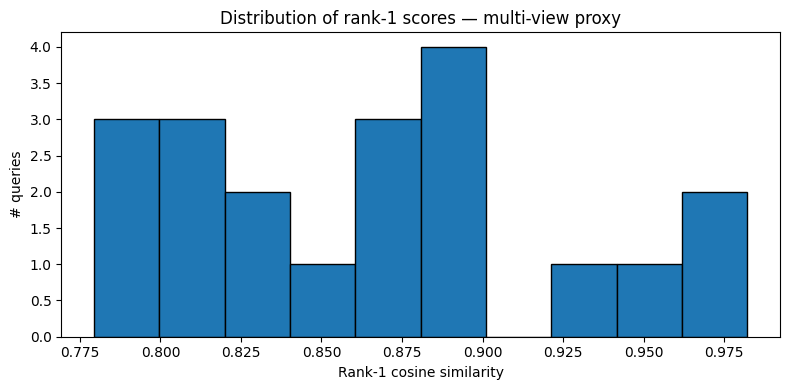

In [17]:
rank1_scores = mv_results_df['mv_rank1_score'].values
print(f"Rank-1 cosine similarity:")
print(f"  min  : {rank1_scores.min():.4f}")
print(f"  mean : {rank1_scores.mean():.4f}")
print(f"  max  : {rank1_scores.max():.4f}")
print(f"  std  : {rank1_scores.std():.4f}")

plt.figure(figsize=(8, 4))
plt.hist(rank1_scores, bins=10, edgecolor='black')
plt.xlabel('Rank-1 cosine similarity')
plt.ylabel('# queries')
plt.title('Distribution of rank-1 scores — multi-view proxy')
plt.tight_layout()
plt.show()

<a id="evaluation"></a>
### **Retrieval Evaluation**

We evaluate retrieval quality using **ball count** as ground truth: a retrieved image is a hit if it has the same number of balls as the query. We compute this for both E2 and E3 so we can compare them directly.

Metrics:
- **P@1** — does the rank-1 image have the same ball count as the query?
- **P@5** — fraction of the top-5 images with the same ball count
- **MAE@1** — absolute difference in ball count between query and rank-1 image

In [18]:
def ball_count(fname, labels_dir):
    p = Path(labels_dir) / (Path(fname).stem + ".txt")
    if not p.exists():
        return None
    return sum(1 for ln in p.read_text().splitlines() if ln.strip() and not ln.startswith('2 '))

TEST_LABELS_DIR = DATA_DIR / "test" / "labels"

# Ball counts for test queries and pool images
query_counts = {row['query_name']: ball_count(row['query_name'], TEST_LABELS_DIR)
                for _, row in mv_results_df.iterrows()}
pool_counts  = {fname: ball_count(fname, TRAIN_LABELS_DIR) for fname in pool_names}

# Load E2 results for comparison
e2_df = pd.read_csv(RESULTS_DIR.parent / 'experiment_02' / 'retrieval_results_resnet.csv')

K = 5
rows = []
for i, row in mv_results_df.iterrows():
    q_name  = row['query_name']
    q_count = query_counts[q_name]

    e3_top5 = [row[f'mv_rank{k}_name'] for k in range(1, K+1)]
    e3_r1   = e3_top5[0]

    e2_row  = e2_df[e2_df['query_idx'] == i].iloc[0]
    e2_top5 = [e2_row[f'resnet_rank{k}_name'] for k in range(1, K+1)]
    e2_r1   = e2_top5[0]

    rows.append({
        'query':    q_name.split('.rf.')[0],
        'q_count':  q_count,
        'e2_r1':    e2_r1.split('.rf.')[0],
        'e2_r1_n':  pool_counts[e2_r1],
        'e2_hit1':  int(pool_counts[e2_r1] == q_count),
        'e2_p5':    sum(pool_counts[f] == q_count for f in e2_top5) / K,
        'e2_mae1':  abs(pool_counts[e2_r1] - q_count),
        'e3_r1':    e3_r1.split('.rf.')[0],
        'e3_r1_n':  pool_counts[e3_r1],
        'e3_hit1':  int(pool_counts[e3_r1] == q_count),
        'e3_p5':    sum(pool_counts[f] == q_count for f in e3_top5) / K,
        'e3_mae1':  abs(pool_counts[e3_r1] - q_count),
    })

eval_df = pd.DataFrame(rows)

# Per-query table
print(f"{'Query':<10}  {'Balls':>5}  {'E2 rank-1':<12}  {'n':>2}  {'✓?':>3}  {'E3 rank-1':<12}  {'n':>2}  {'✓?':>3}")
print('-' * 68)
for _, r in eval_df.iterrows():
    e2_tick = '✓' if r['e2_hit1'] else '✗'
    e3_tick = '✓' if r['e3_hit1'] else '✗'
    print(f"  {r['query']:<10}  {r['q_count']:>5}  {r['e2_r1']:<12}  {r['e2_r1_n']:>2}  {e2_tick:>3}  {r['e3_r1']:<12}  {r['e3_r1_n']:>2}  {e3_tick:>3}")

print()
print(f"{'Metric':<22}  {'E2':>8}  {'E3':>8}")
print('-' * 42)
print(f"  {'P@1 (exact count)':<20}  {eval_df['e2_hit1'].mean():>8.3f}  {eval_df['e3_hit1'].mean():>8.3f}")
print(f"  {'P@5 (exact count)':<20}  {eval_df['e2_p5'].mean():>8.3f}  {eval_df['e3_p5'].mean():>8.3f}")
print(f"  {'MAE@1 (ball count)':<20}  {eval_df['e2_mae1'].mean():>8.3f}  {eval_df['e3_mae1'].mean():>8.3f}")

Query       Balls  E2 rank-1      n   ✓?  E3 rank-1      n   ✓?
--------------------------------------------------------------------
  107_png        14  120_png       15    ✗  106_png       10    ✗
  111_png        16  166_png       14    ✗  163_png        8    ✗
  115_png        11  119_png        9    ✗  24f_png       10    ✗
  118_png        10  162_png       15    ✗  148_png       11    ✗
  134_png        13  150_png       11    ✗  131_png       12    ✗
  136_png        12  150_png       11    ✗  3t_png        15    ✗
  140_png         8  142_png       13    ✗  142_png       13    ✗
  144_png        15  143_png       15    ✓  143_png       15    ✓
  181_png        16  178_png        9    ✗  141_png        7    ✗
  185_png         4  187_png       16    ✗  187_png       16    ✗
  1_png           2  90_png         9    ✗  96_png         6    ✗
  21_png         13  34_png        16    ✗  34_png        16    ✗
  26_png         10  25_png        11    ✗  25_png        11    ✗
  27_png 

<a id="conclusion"></a>
### **Experiment 03 Conclusion**

**Evaluation results**

Ball count is used as ground truth: a retrieval is a hit if the rank-1 image has the same number of balls as the query.

| Metric | E2 (ResNet50 ImageNet) | E3 (Multi-view proxy) |
|---|---|---|
| P@1 (exact ball count) | 0.150 | 0.150 |
| P@5 (exact ball count) | 0.110 | 0.130 |
| MAE@1 (ball count error) | 3.300 | 3.350 |
| Rank-1 mean cosine sim | 0.9520 | 0.8683 |
| Rank-1 std | 0.0326 | 0.0546 |

**E3 did not improve retrieval quality**

P@1 is identical between E2 and E3 (15%), and the exact same 3 queries produce correct hits in both models: `144_png→143_png`, `27_png→34_png`, `52_png→53_png`. These are all adjacent-numbered images from the same match session that happen to share the same ball count — coincidence, not signal. The multi-view proxy changed the geometry of the embedding space (lower mean similarity, wider spread) but did not change *what* is being retrieved.

**Why it did not improve**

The proxy task successfully makes the model viewpoint-invariant for the 25 multi-view groups (suffixed images). But all 20 test queries are bare singleton images — they have no multi-view partner in training and therefore receive no cross-view supervision. Their embeddings remain dominated by visual appearance: table colour, venue banners, broadcast angle. With MAE@1 of ~3.3 balls, the models are retrieving by shooting context, not game state. The worst failure makes this concrete: `185_png` (4 balls) retrieves `187_png` (16 balls) in both models — a 12-ball miss — because both share the same visual broadcast style.

**The root problem**

Both E2 and E3 encode *how and where the image was taken* rather than *what is on the table*. The architecture is not the bottleneck. No feature extractor operating on raw images will solve this as long as venue appearance dominates the embedding.

**Bridge to Experiment 4**

The discussion about using Earth Mover's Distance on ball positions revealed the same issue from a different angle: ball coordinates in image space are viewpoint-dependent. A ball at screen position (0.3, 0.5) in a top-down image and in a broadcast image represent different physical locations on the table. Any position-based similarity metric has the same problem as the embedding — it sees the camera, not the table.

The solution to both problems is the same: **remove the viewpoint geometrically** before computing anything. Experiment 4 does this by detecting the table boundaries and applying a perspective warp to produce a canonical top-down representation in table coordinates. This strips venue colour, banners, and camera geometry, leaving only ball layout. It also enables EMD on ball positions in table space as a proper evaluation metric — one that is viewpoint-invariant and can be applied retrospectively to E2 and E3 as well.

**Note on planned methods 2 and 3 (Contrastive and Triplet Learning)**

The original plan for E3 included contrastive learning and triplet learning in addition to the proxy classification task. These were not pursued. Method 1 revealed that the bottleneck is not the training objective but the information available in the raw image: no metric learning loss — contrastive, triplet, or otherwise — changes what the model sees. As long as venue colour, banners, and camera angle dominate the visual signal, any loss function will learn to separate images by shooting context rather than by ball configuration. The correct intervention is geometric, not metric: E4 normalises away the viewpoint before any feature is extracted, which is the only way to make the downstream similarity meaningful.